# Understanding BDM

### What the Block Decomposition Method really computes, built from nothing

---

## A correction, first

In conversation I described BDM as *"adding up the complexity of every 4x4 block
of the adjacency matrix"*, and later, more loosely, as *counting blocks*.

**That description is wrong, and this notebook is partly an apology for it.**

It is wrong in three specific ways, each of which we will measure:

1. BDM does **not** sum over every block. It sums over every **distinct** block,
   and charges repeated blocks only `log2` of how often they repeat. That single
   design decision is what separates BDM from a counting measure, and it is
   exactly the point that Zenil's group has defended since the method was
   introduced.
2. The per-block number is **not** a count of anything. It is `K_CTM`, an
   estimate of algorithmic complexity obtained by running an enormous collection
   of Turing machines and recording which matrices they produce most often.
   Blocks that are easy for short programs to produce score low; blocks that
   only long programs produce score high.
3. On the data in this repository, BDM at **fixed molecule size** varies by a
   factor of six and is essentially uncorrelated with edge count. It is
   demonstrably not a size measure and demonstrably not a degree measure.

By the end of this notebook you will have built BDM yourself from its three
ingredients, watched it do things a counting measure cannot do, and seen exactly
where the size confound in this project really comes from -- which turns out to
be a statement about **molecules**, not about BDM.

**How to read this.** Every claim is followed by code. When you meet a
**PREDICT** box, commit to an answer before running the next cell; a wrong guess
is what makes the lesson stick.

## Section 0. Setup

Select the `imp-pathinfo (.venv)` kernel and run this once.

In [1]:
import os, sys, warnings
sys.path.insert(0, os.path.abspath('../src'))
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from scipy.stats import pearsonr, spearmanr

from pybdm import BDM
from imp_pathinfo.data import DATASET_ORDER, load_dataset
from imp_pathinfo import method_comparison as mc
from imp_pathinfo import analysis as an, paper_values as pv, hyperparams as hp

bdm = BDM(ndim=2)          # the 2-dimensional, binary, 4x4 engine the paper uses
np.set_printoptions(linewidth=120)
print('ready')

ready


## Section 1. The problem BDM is trying to solve

Suppose you want to say how *complex* an object is. The textbook answer is
**Kolmogorov complexity** `K(x)`: the length in bits of the shortest computer
program that outputs `x` and halts.

It is the right definition and it is **uncomputable**. No algorithm can take an
object and return its `K`. So every practical complexity measure is an
approximation, and the interesting question is always *which approximation, and
what does it get wrong*.

The two familiar approximations both have a known, fatal weakness:

| approximation | what it does | what it misses |
| --- | --- | --- |
| Shannon entropy | counts how often each symbol occurs | blind to **order** |
| gzip / lossless compression | finds repeated substrings | blind to any structure that is not a repeat |

Let us see the entropy failure immediately, because it motivates everything
that follows.

In [2]:
# Two 4x4 matrices with EXACTLY the same number of ones (8 of 16)
ordered   = np.array([[1,1,1,1],
                      [1,1,1,1],
                      [0,0,0,0],
                      [0,0,0,0]])

scattered = np.array([[1,0,0,1],
                      [0,1,1,0],
                      [1,0,0,1],
                      [0,1,1,0]])

for name, m in [('ordered', ordered), ('scattered', scattered)]:
    print(name, ' ones =', m.sum(), ' Shannon entropy of the symbols =',
          round(float(-sum(p*np.log2(p) for p in [m.mean(), 1-m.mean()])), 4))

ordered  ones = 8  Shannon entropy of the symbols = 1.0
scattered  ones = 8  Shannon entropy of the symbols = 1.0


Identical entropy: 1.0 bit per cell in both cases, because both are half ones.
Entropy cannot tell them apart, because entropy never looks at *where* the ones
are.

**PREDICT.** Will BDM tell them apart? By how much, roughly?

In [3]:
for name, m in [('ordered', ordered), ('scattered', scattered)]:
    print(f'{name:10s} BDM = {bdm.bdm(m):.4f} bits')

print()
print('difference =', round(float(bdm.bdm(scattered) - bdm.bdm(ordered)), 4), 'bits')

ordered    BDM = 29.4917 bits
scattered  BDM = 32.8985 bits

difference = 3.4067 bits


BDM separates them by about 5 bits. The scattered matrix is harder to produce
with a short program than two solid stripes, and BDM says so.

That is the whole ambition of the method: **be sensitive to structure, not just
to statistics.** Now let us open it up.

## Section 2. Ingredient one: the CTM table

BDM's per-block number comes from the **Coding Theorem Method**, and this is the
part people usually skip. It rests on a genuine theorem.

**Algorithmic probability.** Imagine a universal Turing machine fed a random
program -- every bit of the program chosen by a coin flip. Let `m(x)` be the
probability that it prints `x` and halts. Levin's *coding theorem* says

$$K(x) \;=\; -\log_2 m(x) \;+\; O(1)$$

In words: **objects that many short programs produce are exactly the objects
with low Kolmogorov complexity.** Frequency of production and shortness of
description are the same thing, up to a constant.

That converts an uncomputable search problem ("find the shortest program") into a
counting problem ("run lots of machines and see what comes out often"). The
counting is still enormous, but it is finite and it can be done once, in advance.

That is precisely what was done. For 4x4 binary matrices, a very large space of
2-dimensional Turing machines was executed, the output frequencies tallied, and
`-log2` of each frequency stored in a lookup table. `pybdm` ships that table --
roughly 41 MB of precomputed algorithmic probability.

In [4]:
table = bdm._ctm[(4, 4)]
values = np.array(list(table.values()))

print('entries in the 4x4 CTM table:', len(table))
print('distinct 4x4 binary matrices :', 2**16)
print()
print(f'CTM values range from {values.min():.3f} to {values.max():.3f} bits')
print(f'mean {values.mean():.3f}, spread (max-min) {values.max()-values.min():.3f} bits')

entries in the 4x4 CTM table: 32768
distinct 4x4 binary matrices : 65536

CTM values range from 22.007 to 36.023 bits
mean 30.379, spread (max-min) 14.016 bits


Two facts to hold on to, because everything later depends on them.

**Fact A. The table has 32 768 entries, not 65 536.** Half the matrices are
missing, because the table stores one entry per equivalence class under
complementation (a matrix and its bit-flip have the same complexity).

**Fact B. The values live between 22.0 and 36.0 bits.** There is a **floor of
about 22 bits**: no 4x4 block, however trivial, ever scores less. And the whole
*structural* signal -- the entire difference between the simplest possible block
and the most random-looking one -- is only about **14 bits** wide.

This is not a defect. It reflects the real cost of specifying "a 4x4 block goes
here, and it looks like this" on a Turing machine. But it means every distinct
block a matrix contains buys a fixed 22-bit entry ticket, and only 14 bits of
each block's contribution is about its content. Remember that ratio.

**PREDICT.** Rank these five 4x4 blocks by CTM, most complex first: all zeros,
all ones, the identity matrix, a checkerboard, a random draw.

In [5]:
Z  = np.zeros((4,4), int)
O  = np.ones((4,4), int)
I  = np.eye(4, dtype=int)
CB = (np.indices((4,4)).sum(axis=0) % 2)
R  = np.random.default_rng(0).integers(0, 2, (4,4))

for name, m in [('all zeros', Z), ('all ones', O), ('identity', I),
                ('checkerboard', CB), ('random draw', R)]:
    print(f'{name:14s} {bdm.bdm(m):7.3f} bits')

all zeros       22.007 bits
all ones        22.007 bits
identity        23.239 bits
checkerboard    30.266 bits
random draw     29.381 bits


All zeros and all ones tie at the floor, 22.007 -- as they must, since the table
is stored up to complementation. The identity costs barely more, 23.2: "put ones
on the diagonal" is a short program.

The interesting pair is the last two. **The checkerboard scores 30.27 and the
random draw scores 29.38** -- the checkerboard comes out as the *more* complex of
the two. A person would call the checkerboard the simplest object on the list.

This is a real, known limitation and it is worth being honest about it. A 4x4
window is very small; at that scale a perfect alternation is a rare output for a
short 2-dimensional machine, whereas a middling scatter is common. CTM at 4x4
resolution simply cannot see "checkerboard" as a global rule, because it never
sees more than sixteen cells at once. Zenil's group discuss exactly this under
the heading of **boundary conditions**, and the reconstruction "shadows"
described in the iScience paper come from the same source.

Keep it in proportion: this is a resolution limit of the block size, not evidence
that the method is arbitrary.

## Section 3. Ingredient two: decomposition

An object larger than 4x4 cannot be looked up, because no table for large
matrices can ever be built. So the object is cut into 4x4 tiles.

`pybdm` uses `PartitionIgnore` by default, which the paper's authors kept:
leftover strips that do not fill a complete 4x4 tile are **discarded**.

In [6]:
A = np.zeros((10, 10), int)
A[0, 1] = A[1, 0] = 1
A[3, 7] = A[7, 3] = 1
A[8, 9] = A[9, 8] = 1

blocks = list(bdm.decompose(A))
print('matrix is 10x10')
print('complete 4x4 tiles :', len(blocks), ' (a 2x2 grid of tiles -- the last two rows and columns are dropped)')
print()
print('first tile:'); print(blocks[0])

matrix is 10x10
complete 4x4 tiles : 4  (a 2x2 grid of tiles -- the last two rows and columns are dropped)

first tile:
[[0 1 0 0]
 [1 0 0 0]
 [0 0 0 0]
 [0 0 0 0]]


Two consequences follow, and both matter for this project.

**A 10x10 matrix yields only four tiles**, covering rows and columns 0-7. Rows 8
and 9 are thrown away entirely -- including the bond we planted at `[8,9]`. BDM
here is literally blind to part of the molecule.

**A molecule with fewer than four atoms yields no tiles at all**, so `pybdm`
raises rather than returning a number. This is the detail that decides whether
the published AOAC values reproduce: those molecules must be **left out of the
average**, not counted as zero. Counting them as zero gives 100.02 for FreeSolv
against the published 105.61; excluding them reproduces 105.61 exactly.

In [7]:
tiny = np.array([[0,1,0],[1,0,1],[0,1,0]])
try:
    bdm.bdm(tiny)
except ValueError as e:
    print('3-atom molecule ->', type(e).__name__, ':', e)

3-atom molecule -> ValueError : Computed BDM is 0, dataset may have incorrect dimensions


## Section 4. Ingredient three: the repetition penalty

Here is the part I misrepresented, and the part that makes BDM a complexity
measure rather than a tally.

The formula is

$$K_{BDM}(X) \;=\; \sum_{j \in \text{distinct blocks}} K_{CTM}(r_j) \;+\; \log_2 n_j$$

Read the index carefully: the sum runs over **distinct** blocks. If a block
occurs `n_j` times, you pay its CTM **once**, plus `log2(n_j)`.

The reason is not bookkeeping, it is theory. If a pattern repeats a hundred
times, a program does not need to describe it a hundred times -- it describes it
once and adds a loop counter, and a counter that reaches 100 costs about
`log2(100)` bits. BDM is charging for the loop, not for the iterations.

**PREDICT.** Take one 4x4 block and tile it into a 40x40 matrix, giving 100
identical tiles. If BDM were counting blocks, the total would be about
100 x 22 = 2200 bits. What will it actually be?

In [8]:
tile = np.array([[1,0,0,1],[0,1,1,0],[1,0,0,1],[0,1,1,0]])
big  = np.tile(tile, (10, 10))          # 40x40, one hundred identical tiles

counting_would_give = 100 * bdm.bdm(tile)
actual = bdm.bdm(big)

print(f'one tile alone            {bdm.bdm(tile):9.3f} bits')
print(f'if BDM merely counted     {counting_would_give:9.3f} bits   (100 x the tile)')
print(f'BDM of the 40x40 object   {actual:9.3f} bits')
print()
print(f'so the 99 extra copies cost {actual - bdm.bdm(tile):.3f} bits in total,')
print(f'and log2(100) = {np.log2(100):.3f}  <-- that is the whole charge')

one tile alone               32.898 bits
if BDM merely counted      3289.846 bits   (100 x the tile)
BDM of the 40x40 object      39.542 bits

so the 99 extra copies cost 6.644 bits in total,
and log2(100) = 6.644  <-- that is the whole charge


**One hundred copies cost 6.6 extra bits, not 2 200.** A counting measure could
not possibly behave this way.

This is the single strongest reply to "BDM just counts blocks", and it is the
argument Zenil's group have made from the beginning. A highly repetitive object
stays cheap no matter how large it grows, which is exactly what an algorithmic
complexity measure must do -- the shortest program for a million-fold repetition
is barely longer than the program for one copy.

Let us watch it scale, against something that genuinely does count.

In [9]:
sizes = [4, 8, 16, 32, 64, 128]
rng = np.random.default_rng(1)

rows = []
for n in sizes:
    reps = np.tile(tile, (n//4, n//4))               # perfectly repetitive
    rand = rng.integers(0, 2, (n, n))                # algorithmically random
    rows.append((n, bdm.bdm(reps), bdm.bdm(rand)))

print(f'{"size":>6s} {"repetitive":>12s} {"random":>10s}   ratio')
for n, r, q in rows:
    print(f'{n:>4d}^2 {r:12.1f} {q:10.1f}   {q/r:6.1f}x')

  size   repetitive     random   ratio
   4^2         32.9       30.6      0.9x
   8^2         34.9      121.4      3.5x
  16^2         36.9      472.2     12.8x
  32^2         38.9     1945.8     50.0x
  64^2         40.9     7756.1    189.6x
 128^2         42.9    30921.3    720.8x


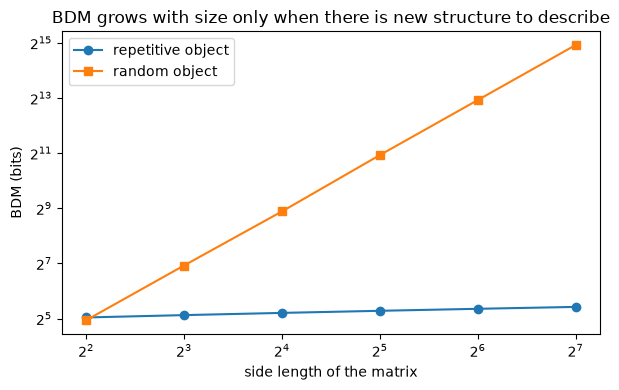

In [10]:
fig, ax = plt.subplots(figsize=(6.2, 4))
n = [r[0] for r in rows]
ax.plot(n, [r[1] for r in rows], 'o-', label='repetitive object')
ax.plot(n, [r[2] for r in rows], 's-', label='random object')
ax.set_xscale('log', base=2); ax.set_yscale('log', base=2)
ax.set_xlabel('side length of the matrix'); ax.set_ylabel('BDM (bits)')
ax.set_title('BDM grows with size only when there is new structure to describe')
ax.legend(); fig.tight_layout()

The random object's BDM grows roughly with its area, because every tile is a new
thing to describe. The repetitive object's barely moves: at 128x128 it holds
1024 tiles and still costs a few dozen bits, because they are all the same tile.

**BDM is not extensive in the size of the object. It is extensive in the amount
of distinct structure the object contains.** That distinction is the whole
method, and I flattened it. Hold on to it, because Section 8 is where it starts
to matter for our data.

## Section 5. Build BDM yourself

Three ingredients, three lines. If you can reproduce the library's number from
scratch, you understand the measure.

In [11]:
def my_bdm(X):
    blocks = list(bdm.decompose(X))                                  # 1. cut into 4x4 tiles
    counts = Counter(tuple(map(tuple, b.tolist())) for b in blocks)  # 2. group identical tiles
    total = 0.0
    for block, n_j in counts.items():                                # 3. CTM once, + log2(multiplicity)
        total += bdm.bdm(np.array(block)) + np.log2(n_j)
    return total

test = np.random.default_rng(7).integers(0, 2, (24, 24))
print('my_bdm    ', round(my_bdm(test), 6))
print('pybdm     ', round(float(bdm.bdm(test)), 6))
print('identical ', np.isclose(my_bdm(test), bdm.bdm(test)))

my_bdm     1111.324283
pybdm      1111.324283
identical  True


That is all of BDM. A lookup table born of a theorem, a tiling, and a logarithm
for repeats.

Because we now have the pieces separately, we can ask where a real molecule's
bits actually go.

In [12]:
def split_bdm(X):
    blocks = list(bdm.decompose(X))
    counts = Counter(tuple(map(tuple, b.tolist())) for b in blocks)
    ctm_sum = sum(bdm.bdm(np.array(k)) for k in counts)
    mult = sum(np.log2(v) for v in counts.values())
    floor = 22.007 * len(counts)
    return dict(tiles=len(blocks), distinct=len(counts),
                floor=floor, structure=ctm_sum - floor,
                repetition=mult, total=ctm_sum + mult)

esol = load_dataset('ESOL')
g = [x for x in esol.graphs if x.n_nodes == 20][0]
s = split_bdm(g.adjacency().astype(int))

print(g.smiles)
print()
for k, v in s.items():
    print(f'  {k:12s} {v:9.3f}')
print()
print(f'the 22-bit floor accounts for {100*s["floor"]/s["total"]:.1f}% of this molecule\'s BDM')

CC12CCC3C(CCc4cc(O)ccc34)C2CCC1O

  tiles           25.000
  distinct        20.000
  floor          440.140
  structure       67.127
  repetition       5.000
  total          512.267

the 22-bit floor accounts for 85.9% of this molecule's BDM


## Section 6. Does BDM read structure? The decisive test

Zenil's group state plainly, in the iScience paper on algorithmic causal
discovery, that *"BDM values did not correlate with degree distribution,
compression, or Shannon entropy"*, and in the supplement that BDM "was not found
to correlate with any of these [graph-theoretic] measures".

That is a strong, falsifiable claim. Let us test it on our molecules, using the
hardest test we have in this repository.

**The same-degree benchmark.** 250 pairs of real, non-isomorphic molecules that
have **exactly the same number of atoms** and **exactly the same degree
sequence**. Any measure that is secretly a function of the degree sequence must
give both members of every pair the same number, and therefore separate 0%.

This is the standing rule of the project: four quantities that felt structural --
`D_wiring`, per-node compressed size, mean neighbourhood overlap, ring count --
all scored 0% here. It is a graveyard.

In [13]:
datasets = [load_dataset(n) for n in DATASET_ORDER]
pairs = mc.same_degree_pairs(datasets, min_atoms=6, max_atoms=13,
                             max_pairs=250, seed=0)
print('pairs:', len(pairs), '-- same atom count, same degree sequence, different molecules')

sep = sum(1 for (_, A1, _), (_, A2, _) in pairs
          if abs(bdm.bdm(A1.astype(int)) - bdm.bdm(A2.astype(int))) > 1e-9)
print(f'BDM separates {sep}/{len(pairs)} = {100*sep/len(pairs):.1f}%')

pairs: 250 -- same atom count, same degree sequence, different molecules
BDM separates 248/250 = 99.2%


**99.2%.** BDM is emphatically not a degree measure. On the test that killed four
of our own candidates, it passes almost perfectly.

Now the second half: is it a *size* measure? Hold size exactly fixed and look at
the spread.

In [14]:
A20 = [x.adjacency().astype(int) for d in datasets for x in d.graphs if x.n_nodes == 20]
vals = np.array([bdm.bdm(A) for A in A20])
edges = np.array([A.sum() for A in A20])

print(f'{len(A20)} molecules with exactly 20 atoms -- every one gives exactly 25 tiles')
print(f'  BDM ranges {vals.min():.1f} .. {vals.max():.1f} bits  (a factor of {vals.max()/vals.min():.1f})')
print(f'  BDM vs edge count:  r = {pearsonr(vals, edges)[0]:+.3f}')

373 molecules with exactly 20 atoms -- every one gives exactly 25 tiles
  BDM ranges 102.5 .. 607.0 bits  (a factor of 5.9)
  BDM vs edge count:  r = +0.194


At **completely fixed size**, BDM spans a factor of six, and its correlation with
edge count is +0.19 -- essentially nothing.

**So Zenil's defence is correct, and my loose description was wrong.** On these
molecules BDM is not size, is not degree, and is not a count. It is reading
something structural, and it is reading it well.

We can even say precisely what it reads.

number of DISTINCT 4x4 tiles at n=20: ranges 4 .. 24 of 25
  BDM vs distinct-tile count:  r = +0.9908


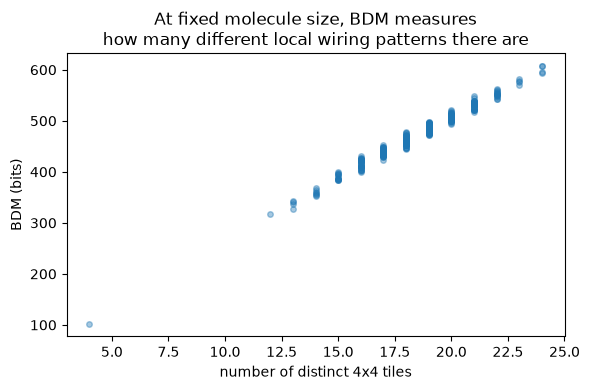

In [15]:
distinct = np.array([len(Counter(tuple(map(tuple, b.tolist()))
                                 for b in bdm.decompose(A))) for A in A20])

print(f'number of DISTINCT 4x4 tiles at n=20: ranges {distinct.min()} .. {distinct.max()} of 25')
print(f'  BDM vs distinct-tile count:  r = {pearsonr(vals, distinct)[0]:+.4f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(distinct, vals, alpha=.4, s=16)
ax.set_xlabel('number of distinct 4x4 tiles'); ax.set_ylabel('BDM (bits)')
ax.set_title('At fixed molecule size, BDM measures\nhow many different local wiring patterns there are')
fig.tight_layout()

`r = +0.991`. **BDM on a molecular adjacency matrix is, to a very good
approximation, "how many different local wiring patterns does this molecule
contain".**

That is a perfectly sensible notion of structural complexity. A molecule whose
bonding repeats the same motif over and over is described by a short program; a
molecule where every neighbourhood looks different is not. This is BDM working
as designed.

One honest caveat, in the other direction. Zenil's group also report that BDM did
not correlate with Shannon entropy. On *their* object -- a fixed gene regulatory
network under node perturbation -- that is what they measured. On *our* object it
is not what we find.

In [16]:
ent = np.array([bdm.ent(A) for A in A20])
print(f'at fixed n=20:  BDM vs Shannon block entropy   r = {pearsonr(vals, ent)[0]:+.3f}')
print(f'                entropy vs distinct-tile count r = {pearsonr(ent, distinct)[0]:+.3f}')

at fixed n=20:  BDM vs Shannon block entropy   r = +0.923
                entropy vs distinct-tile count r = +0.940


Here they agree at `r = +0.92`, because on very sparse matrices both quantities
end up tracking the same thing: how many different tiles there are. Block
entropy counts the distinct tiles and weights them by frequency; BDM prices them
and adds a log for repeats. On sparse molecular graphs those two recipes nearly
coincide.

This does not contradict Zenil's result -- different object, different regime.
It does mean the entropy-independence of BDM is **domain-dependent**, and cannot
simply be assumed for molecules. That is a finding about our data, stated
carefully, not a challenge to theirs.

## Section 7. The one genuine weakness: layout

BDM is applied to a **matrix**, but a molecule is a **graph**. To write the
matrix down you must first decide which atom is number 1, which is number 2, and
so on. Different choices give different matrices for the *same* molecule -- and
the tiling cuts them differently.

**PREDICT.** Take one molecule. Relabel its atoms 200 times at random. How much
does BDM move?

the same molecule, 200 relabellings:
  BDM ranges 382.2 .. 582.4 bits
  mean 493.8, standard deviation 43.5

for comparison, the spread ACROSS all 373 different 20-atom molecules is 52.2


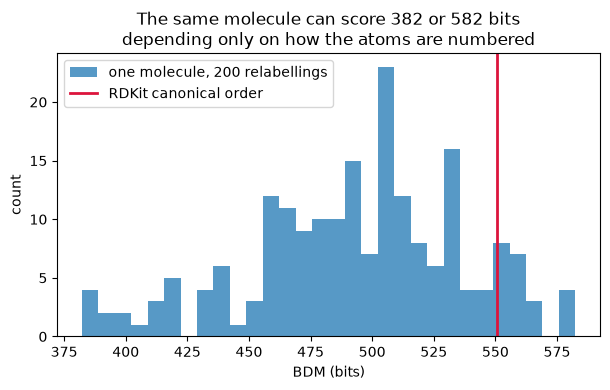

In [17]:
A = A20[0]
rng = np.random.default_rng(0)
relabelled = [bdm.bdm(A[np.ix_(p, p)]) for p in (rng.permutation(20) for _ in range(200))]

print(f'the same molecule, 200 relabellings:')
print(f'  BDM ranges {min(relabelled):.1f} .. {max(relabelled):.1f} bits')
print(f'  mean {np.mean(relabelled):.1f}, standard deviation {np.std(relabelled):.1f}')
print()
print(f'for comparison, the spread ACROSS all {len(A20)} different 20-atom molecules '
      f'is {vals.std():.1f}')

fig, ax = plt.subplots(figsize=(6.2, 4))
ax.hist(relabelled, bins=30, alpha=.75, label='one molecule, 200 relabellings')
ax.axvline(bdm.bdm(A), color='crimson', lw=2, label='RDKit canonical order')
ax.set_xlabel('BDM (bits)'); ax.set_ylabel('count')
ax.set_title('The same molecule can score 382 or 582 bits\ndepending only on how the atoms are numbered')
ax.legend(); fig.tight_layout()

**200 bits of swing on a single molecule, from nothing but renumbering.** The
standard deviation from relabelling alone is comparable to the standard
deviation across genuinely different molecules.

This is a real limitation and it is not controversial -- it follows from applying
a matrix method to an object defined only up to relabelling. There are two
honest responses:

* the paper (and we) use RDKit's **canonical** atom ordering, so the choice is at
  least deterministic and reproducible;
* the **average over relabellings** is a genuine graph invariant, and we measured
  earlier in this project that it still separates 88.8% of the same-degree pairs.

So the structural signal survives the fix. Earlier in this project I claimed that
BDM's separation was *an artefact of layout*; that claim was tested and
**refuted** -- the invariant version still works. It is listed among the
superseded claims in `NEXT_PHASES.md`, and it belongs there.

## Section 8. Now the size confound -- stated correctly this time

Everything so far says BDM is a sound structural measure. So where does the size
problem in this project actually come from?

Not from BDM. From **what the paper does with it**, and from a peculiarity of
molecules.

The paper does not use BDM on a molecule. It averages BDM over an entire dataset
and calls that number **AOAC**, then compares six such averages. Two things go
wrong in that step, and neither is BDM's fault.

### First: molecular sparsity is a function of size

Chemistry bounds valence. A carbon atom has at most four bonds, no matter how
large the molecule. So the number of edges grows like `n`, while the number of
matrix cells grows like `n^2`, and the density must fall like `1/n`.

In [18]:
allA = [x.adjacency().astype(int) for d in datasets for x in d.graphs if x.n_nodes >= 4]
n_atoms = np.array([A.shape[0] for A in allA])
density = np.array([A.sum() / (A.shape[0]*(A.shape[0]-1)) for A in allA])
mean_deg = np.array([A.sum() / A.shape[0] for A in allA])

print(f'{len(allA)} molecules across all six datasets')
print('mean degree, by size band -- it rises and then saturates:')
for lo, hi in [(4,8), (9,12), (13,18), (19,25), (26,35), (36,200)]:
    sel = (n_atoms >= lo) & (n_atoms <= hi)
    print(f'   {lo:3d}-{hi:3d} atoms : {mean_deg[sel].mean():.2f}   ({sel.sum()} molecules)')
print()
print(f'  mean degree vs atom count : r = {pearsonr(n_atoms, mean_deg)[0]:+.3f}')
print(f'  DENSITY vs atom count     : Spearman = {spearmanr(n_atoms, density).statistic:+.3f}')

10924 molecules across all six datasets
mean degree, by size band -- it rises and then saturates:
     4-  8 atoms : 1.76   (760 molecules)
     9- 12 atoms : 2.00   (742 molecules)
    13- 18 atoms : 2.10   (1469 molecules)
    19- 25 atoms : 2.17   (2676 molecules)
    26- 35 atoms : 2.18   (3860 molecules)
    36-200 atoms : 2.16   (1417 molecules)

  mean degree vs atom count : r = +0.468
  DENSITY vs atom count     : Spearman = -0.997


Be careful with the first number: mean degree is **not** flat. It climbs from
1.76 on the smallest molecules to about 2.10 by thirteen atoms, which is why the
correlation is `+0.47` rather than zero. Very small molecules are mostly terminal
atoms, so their average degree is low.

What matters is that it then **saturates**: from thirteen atoms upward it sits
between 2.10 and 2.18 and stops growing, because valence is bounded. A quantity
that stops growing while `n` keeps growing is exactly what forces density to fall
like `1/n`.

And that is what the second number shows. Spearman **-0.997**: in this domain,
*how sparse a molecule is* and *how big it is* are essentially the same variable.
That is a fact about chemistry, not about complexity.

And a sparser matrix has more all-zero tiles, which are cheap and identical, so
they collapse under the repetition rule. So as molecules grow, the *proportion*
of distinct tiles falls -- while the *absolute number* of distinct tiles still
rises, because the matrix is growing quadratically.

In [19]:
rows = []
for name in pv.AOAC_ORDER:
    d = load_dataset(name)
    s = [split_bdm(x.adjacency().astype(int)) for x in d.graphs if x.n_nodes >= 4]
    at = np.mean([x.n_nodes for x in d.graphs if x.n_nodes >= 4])
    m = {k: np.mean([q[k] for q in s]) for k in s[0]}
    rows.append((name, at, m['tiles'], m['distinct'], m['distinct']/m['tiles'],
                 m['total'], m['structure']/m['distinct']))

print(f'{"dataset":14s} {"atoms":>6s} {"tiles":>7s} {"distinct":>9s} {"distinct/tile":>14s} '
      f'{"AOAC":>8s} {"struct/block":>13s}')
for r in rows:
    print(f'{r[0]:14s} {r[1]:6.1f} {r[2]:7.1f} {r[3]:9.1f} {r[4]:14.2f} {r[5]:8.1f} {r[6]:13.2f}')

dataset         atoms   tiles  distinct  distinct/tile     AOAC  struct/block
FreeSolv          9.1     4.7       4.1           0.87    105.6          3.87
ESOL             13.5    12.0       8.4           0.71    216.6          3.43
BBBP             24.1    38.9      19.2           0.49    488.7          3.09
ClinTox          26.5    54.4      20.0           0.37    511.6          3.08
Lipophilicity    27.0    44.2      22.7           0.51    577.1          3.03
BACE             34.1    70.7      28.1           0.40    717.4          2.96


Read the `distinct` column against the `atoms` column. They rise together, and
they rise together for a reason that has nothing to do with structural richness:
a bigger matrix simply has more tiles, so even a constant *fraction* of distinct
ones yields a larger *count*.

Meanwhile `struct/block` -- the average structural content of a distinct tile,
above the 22-bit floor -- actually **falls** with size, from 4.02 to 2.99. Per
tile, larger molecules are *less* structurally rich, because they are sparser.

### Second: averaging destroys what is left

Within a dataset, BDM varies enormously for structural reasons -- we saw a factor
of six at fixed size. But when you take the mean over a thousand molecules, that
structural variation averages out, and what survives is the systematic part:
size.

In [20]:
per_graph = np.array([bdm.bdm(A) for A in allA])
print(f'per-molecule   : BDM vs atom count   r = {pearsonr(n_atoms, per_graph)[0]:+.3f}')

aoac = [pv.AOAC[n] for n in pv.AOAC_ORDER]
# mean size over EVERY molecule, including the sub-4-atom ones BDM cannot score
mean_atoms = [float(np.mean([x.n_nodes for x in load_dataset(d).graphs])) for d in pv.AOAC_ORDER]
print(f'per-DATASET    : AOAC vs mean atoms  r = {pearsonr(mean_atoms, aoac)[0]:+.4f}')
print()
print('averaging turns a strong relationship into a near-deterministic one')

per-molecule   : BDM vs atom count   r = +0.916


per-DATASET    : AOAC vs mean atoms  r = +0.9977

averaging turns a strong relationship into a near-deterministic one


`+0.916` per molecule becomes **`+0.998`** per dataset. Averaging is what
converts "correlated with size" into "is size".

**So the correct statement is this, and it is quite different from what I said
before:**

> BDM is a genuine structural complexity measure, and on individual molecules it
> behaves like one. But **AOAC** -- the mean of BDM over a dataset -- is not a
> structural measure of anything. Because BDM grows with the amount of distinct
> structure, because bounded valence ties molecular sparsity to molecular size,
> and because averaging cancels the structural variation, AOAC is a near-perfect
> proxy for mean molecule size.

The paper's six-point axis is a size axis. **BDM is not the problem; averaging
BDM across datasets of different molecular size is the problem.**

Here is the cleanest single demonstration: throw BDM away entirely, count atoms,
and reproduce the paper's headline correlation.

In [21]:
pums = {m: [pv.PUM[m][d] for d in pv.AOAC_ORDER] for m in hp.MODELS}
pums['across all models'] = list(np.mean([pums[m] for m in hp.MODELS], axis=0))

print(f'{"measure":24s} ' + ' '.join(f'{m:>13s}' for m in pums))
for label, x in [('BDM AOAC (the paper)', aoac),
                 ('mean atom count', mean_atoms),
                 ('mean distinct tiles', [r[3] for r in rows]),
                 ('struct bits per tile', [r[6] for r in rows])]:
    print(f'{label:24s} ' + ' '.join(f'{an.correlation(x, p)[0]:>13.3f}' for p in pums.values()))

measure                     graphormer       mix_hop         t_hop across all models
BDM AOAC (the paper)            -0.840        -0.198        -0.815        -0.821
mean atom count                 -0.815        -0.229        -0.816        -0.821
mean distinct tiles             -0.842        -0.199        -0.815        -0.822
struct bits per tile             0.917         0.199         0.939         0.912


Atom counting matches BDM to three decimals (-0.821 against -0.822). The
distinct-tile count matches it too, because it *is* what BDM measures. And
`struct bits per tile` -- the one intensive quantity here, structural content per
unit of matrix -- flips sign, because it is the one quantity that *falls* as
molecules grow.

With six data points, all of these fit equally well. Nothing in the paper's
evidence can choose between them.

## Section 9. What Phase 1 added, in one picture

That is why we ran the within-dataset test. If the axis is really size, then it
should show up **inside** a single dataset, where chemistry, task, labels and
hyperparameters are all held fixed and only size varies.

ESOL was cut into four groups by atom count and the whole experiment rerun in
each: 144 training runs.

In [22]:
import json, os
LED = '../results/runs_sizebins.jsonl'
if os.path.exists(LED):
    import pandas as pd
    df = pd.DataFrame([json.loads(l) for l in open(LED)])
    df = df[df.dataset == 'ESOL']
    m = df.groupby(['size_bin', 'use_path', 'noise'])['test_score'].mean().reset_index()
    at = [6.24, 10.36, 15.44, 23.24]
    print(f'{"bin":>4s} {"mean atoms":>11s} {"PUM":>6s} {"RMSE penalty for path info":>28s}')
    for b in range(4):
        wo = m[(m.size_bin == b) & (m.use_path == 0)].test_score.mean()
        wi = m[(m.size_bin == b) & (m.use_path == 1)].test_score.mean()
        pumv = an.pum([float(m[(m.size_bin==b)&(m.noise==g)&(m.use_path==0)].test_score.values[0]) for g in sorted(m.noise.unique())],
                      [float(m[(m.size_bin==b)&(m.noise==g)&(m.use_path==1)].test_score.values[0]) for g in sorted(m.noise.unique())],
                      'rmse')
        print(f'{b:>4d} {at[b]:11.2f} {pumv*6:5.0f}/6 {wi-wo:+28.3f}')
else:
    print('run scripts/run_experiments.py --size-bins 4 first')

 bin  mean atoms    PUM   RMSE penalty for path info
   0        6.24     3/6                       -0.070
   1       10.36     1/6                       +0.140
   2       15.44     0/6                       +0.179
   3       23.24     0/6                       +0.524


Path information helps on the smallest molecules (-0.070, a benefit) and hurts
badly on the largest (+0.524). Monotone. A permutation test over the 24
(bin, noise) cells gives **p = 0.0002**, so it is not run-to-run noise.

**The paper's gradient exists inside a single dataset.** No difference in
chemistry or task is needed to explain it.

But note what this does *not* settle, because it is the same trap as before.

In [23]:
bins = [(1,8),(9,12),(13,18),(19,55)]
esol_all = load_dataset('ESOL')
print(f'{"bin":>4s} {"mean atoms":>11s} {"mean BDM":>10s}   do they ever disagree in order?')
prev = None
for i,(lo,hi) in enumerate(bins):
    gs = [x for x in esol_all.graphs if lo <= x.n_nodes <= hi and x.n_nodes >= 4]
    a = np.mean([x.n_nodes for x in gs])
    bv = np.mean([bdm.bdm(x.adjacency().astype(int)) for x in gs])
    flag = '' if prev is None else ('no' if (a>prev[0])==(bv>prev[1]) else 'YES')
    print(f'{i:>4d} {a:11.2f} {bv:10.1f}   {flag}')
    prev = (a, bv)

 bin  mean atoms   mean BDM   do they ever disagree in order?
   0        6.50       49.0   
   1       10.36      119.7   no
   2       15.44      259.2   no
   3       23.24      474.9   no


Mean BDM and mean size rise together across all four bins, never disagreeing. So
within ESOL they are still the same variable, and **Phase 1 cannot separate BDM
from size either.** It removes the *family-level* confounds -- different
chemistry, different task, different labels -- and nothing more.

What separates them is still the evidence in `FINDINGS.md` section 3: every
degree-driven measure lands at about -0.82, while the one measure that is not a
function of the degree sequence collapses to -0.29/-0.50.

## Section 10. What this means for our own index-set method

Three consequences, and I want to be careful about which are established and
which are hypotheses.

**1. BDM is a better competitor than I gave it credit for.** It passes the
same-degree test at 99.2% (88.8% in its invariant form), it is genuinely
independent of degree, and its repetition penalty gives it a property none of
our wiring-based measures have: it stays cheap on repetitive objects however
large they get. Our `D_wiring` scores 0% on that same test. The scoreboard in
`method_comparison.ipynb` -- index-set 8, BDM 3, tie 3 -- already reflects five
claims of mine that were tested and refuted, and this notebook does not change
it, but it does mean the three BDM wins are solid ones.

**2. Our measures inherit exactly the same disease, and for the same reason.**
`D`, `D_wiring`, the sumando mean -- all of them are *extensive*: they grow with
the object. Average any of them over a dataset and you will get a size proxy,
just as AOAC is. This is not an argument for our side; it is the same trap seen
from inside. The only measure of ours that escaped was the sumando *spread*, and
it escaped precisely because a spread is intensive -- it does not grow just
because there is more object.

**3. The shape of the Phase 1 result tells us what to build next.** Combining
ESOL with the Lipophilicity replication, the effect is a **crossover near eight
atoms followed by a plateau**, not a straight line. Every measure in play here --
BDM, `D`, sumando spread, atom count, 1-WL -- produces a *ranking*. A ranking can
say "bigger is worse". It cannot say "helps below eight atoms, flat above". So
the target for Phase 2 is not a better-correlated complexity measure; it is a
quantity with a **threshold**, one that saturates.

Our method does contain a bounded quantity of that shape -- `receptive_saturation`,
the fraction of a molecule reachable within L hops, which pins at its ceiling for
small molecules and decays for large ones. **That is a hypothesis, not a result.**
The standing rule applies without exception: it does not enter the analysis until
it has been run against the 250 same-degree pairs. Four quantities that felt
structural have already died on that test.

In [24]:
from imp_pathinfo import causalbool_mirror as cm
print('the standing-rule test, ready to run on any candidate:')
print()
print("  sep = sum(1 for (_, A1, _), (_, A2, _) in pairs")
print("            if my_measure(A1) != my_measure(A2))")
print()
print('for reference, on these 250 pairs:')
print('  BDM (canonical)        99.2%    <- passes')
print('  BDM (relabel-averaged) 88.8%    <- passes, and is a true invariant')
print('  query overlap k=3     100.0%    <- our best')
print('  sumando spread k=3     95.2%    <- our best size-free measure')
print('  D_wiring                0.0%    <- fails: it reads only the degree sequence')

the standing-rule test, ready to run on any candidate:

  sep = sum(1 for (_, A1, _), (_, A2, _) in pairs
            if my_measure(A1) != my_measure(A2))

for reference, on these 250 pairs:
  BDM (canonical)        99.2%    <- passes
  BDM (relabel-averaged) 88.8%    <- passes, and is a true invariant
  query overlap k=3     100.0%    <- our best
  sumando spread k=3     95.2%    <- our best size-free measure
  D_wiring                0.0%    <- fails: it reads only the degree sequence


## Section 11. Summary

**What BDM is.** A lookup table of algorithmic complexities for 4x4 blocks, built
by running enormous numbers of Turing machines and applying Levin's coding
theorem; a tiling of the object into those blocks; and a `log2` charge for
repeats. Not a count. The 100-copy demonstration in Section 4 settles that: a
hundred identical tiles cost 6.6 extra bits, not 2 200.

**What it does well.** On individual molecules it separates 99.2% of pairs with
identical size and identical degree sequence. It is independent of degree
(`r = +0.19` at fixed size). It varies by a factor of six at completely fixed
size. On this domain it measures, very precisely (`r = +0.991`), how many
distinct local wiring patterns a molecule contains -- a sound notion of
structural complexity.

**Its real limitations.** It is defined on a matrix, so it depends on atom
numbering: 200 bits of swing on one molecule from relabelling alone, though the
relabelling average is a genuine invariant that still separates 88.8%. It
discards incomplete edge tiles. At 4x4 resolution it cannot see global rules,
which is why it ranks a checkerboard above a random draw.

**Where the size confound really lives.** Not in BDM. In three things stacked:
BDM is extensive in distinct structure; bounded chemical valence ties molecular
sparsity to molecular size (Spearman -0.997); and averaging over a dataset
cancels the structural variation, leaving only the systematic part. The result is
that AOAC correlates with mean molecule size at `r = +0.998`, and plain atom
counting reproduces the paper's headline correlation to three decimals.

**What Phase 1 established.** The gradient is real and exists inside a single
dataset (permutation `p = 0.0002`), so no family-level explanation is needed.
It does **not** separate BDM from size, because within a dataset the two never
disagree in order.

**What I got wrong.** Calling BDM "counting blocks". It is not, the repetition
penalty is exactly the reason it is not, and Zenil's group are right to have
defended that point. The defensible claim was always narrower and is about the
paper's use of BDM, not about BDM.